In [1]:
import gc
import os
import multiprocessing
from torchvision.transforms import v2
from climate_cnn import ClimateCNN
from koppen_dataset import KoppenDataset
import torch
import torch.nn as nn
import tensorflow as tf
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
from torch.amp import autocast
from tqdm.auto import tqdm
from model.dataloader import load_shards
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns

In [2]:
# 1. Is CUDA available?
print(f"Is CUDA available? {torch.cuda.is_available()}")

# 2. Which version of CUDA was PyTorch built with?
print(f"PyTorch CUDA version: {torch.version.cuda}")

# 3. What is the name of your GPU?
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch cannot find your GPU.")

Is CUDA available? True
PyTorch CUDA version: 12.8
GPU Name: NVIDIA GeForce RTX 3070


In [3]:
# Force TensorFlow to use CPU only so PyTorch has the whole GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Verify TF doesn't see the GPU
print(tf.config.list_physical_devices('GPU')) # Should return []

[]


In [4]:
# Load the data from the drive
# Use your local filepath here
file_pattern = r'G:/.shortcut-targets-by-id/1abX3CWvYUSJM3cGg6r_GeHAVeNoYH6Ul/CS6140_Project_Data/koppen_shard_part_*.tfrecord.gz'
all_files = tf.io.gfile.glob(file_pattern)
print(len(all_files), 'shards loaded')

# Split training and testing data
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

1500 shards loaded


In [5]:
# Function to calculate mean and std of training and testing sets
def calculate_stats(tf_dataset, num_samples=5000):
    images_iterator = tf_dataset.unbatch().take(num_samples).as_numpy_iterator()
    all_images = np.stack([img for img, _ in images_iterator])

    means = np.mean(all_images, axis=(0, 1, 2))
    stds = np.std(all_images, axis=(0, 1, 2))

    return means.tolist(), stds.tolist()

In [6]:
# Function to count the number of training batches
def count_batches(dataset):
    count = 0
    for _ in dataset:
        count += 1
    return count

In [7]:
# Load raw data to calculate normalization statistics
loader_batch_size = 64
cores = multiprocessing.cpu_count()
train_raw = load_shards(train_files, batch_size=loader_batch_size)
val_raw = load_shards(val_files, batch_size=loader_batch_size)
train_means, train_stds = calculate_stats(train_raw)
total_train_steps = count_batches(train_raw)

# Minimal transforms to perform on CPU
cpu_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=False),
])

# For Training: High variety to fight overfitting
train_gpu_transforms = v2.Compose([
    v2.Resize(224, antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(180),
    v2.RandomResizedCrop(224, scale=(0.8, 1.0), antialias=True),
    v2.Normalize(mean=train_means, std=train_stds) # Normalizing on GPU is faster
])

# For Validation: No randomness
val_gpu_transforms = v2.Compose([
    v2.Resize(224, antialias=True),
    v2.Normalize(mean=train_means, std=train_stds)
])

# Create dataloaders
train_loader = DataLoader(
    KoppenDataset(train_raw, cpu_transforms),
    batch_size=None,
    pin_memory=True
)
val_loader = DataLoader(
    KoppenDataset(val_raw, cpu_transforms),
    batch_size=None,
    pin_memory=True
)

In [8]:
# Function for checkpointing model during training
def save_checkpoint(state, filename="models/koppen_checkpoint.pth"):
    print(f"=> Saving best model to {filename}")
    torch.save(state, filename)

In [9]:
# Function for loading model checkpoint
def load_checkpoint(checkpoint_path, model, optimizer, scheduler):
    print(f"=> Loading checkpoint '{checkpoint_path}'")
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    start_epoch = checkpoint['epoch']
    best_acc = checkpoint['best_acc']

    return model, optimizer, scheduler, start_epoch, best_acc

In [10]:
# Training Loop Function
def train_model(
        model,
        train_dataloader,
        test_dataloader,
        criterion,
        optimizer,
        scheduler,
        train_steps=None,
        num_epochs=10,
        start_epoch=0,
        best_val_acc=0
):
    # Set device to CUDA GPU if enabled
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_acc = best_val_acc
    best_val_loss = 0
    epochs_without_improvement = 0
    total_steps = train_steps if train_steps is not None else None

    training_losses = []
    training_accuracies = []
    validation_losses = []
    validation_accuracies = []

    for epoch in range(start_epoch, num_epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_dataloader, total=total_steps, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]")

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            # Apply image augmentation
            images = train_gpu_transforms(images)

            optimizer.zero_grad()

            # Forward pass with auto-casting
            with autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Backward pass with scaled loss
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar with current memory usage
            mem = torch.cuda.memory_reserved(0) / 1024**2
            progress_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{100.*correct/total:.2f}%", "VRAM": f"{mem:.0f}MB"})

        # Append training loss/accuracy to plot data
        training_losses.append(running_loss / total)
        training_accuracies.append(100 * correct / total)

        # --- Validation ---
        model.eval()
        validation_loss = 0.0
        validation_correct = 0
        validation_total = 0

        with torch.no_grad():
            for images, labels in test_dataloader:
                images, labels = images.to(device), labels.to(device)

                # Apply image augmentation
                images = val_gpu_transforms(images)

                with autocast(device_type='cuda', dtype=torch.bfloat16):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                validation_loss += loss.item()
                _, predicted = outputs.max(1)
                validation_total += labels.size(0)
                validation_correct += (predicted == labels).sum().item()

        avg_val_loss = validation_loss / validation_total
        current_val_acc = 100. * validation_correct / validation_total

        # Step the LR scheduler
        scheduler.step(avg_val_loss)

        # Append validation loss/accuracy to plot data
        validation_losses.append(avg_val_loss)
        validation_accuracies.append(current_val_acc)

        # Check if this is the best version so far
        if current_val_acc > best_val_acc:
            best_val_acc = current_val_acc
            save_checkpoint({
                'epoch': epoch + 1,
                'state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'best_acc': best_val_acc,
                'means': train_means,
                'stds': train_stds
            })

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement == 5:
            print("Five epochs without validation loss improvement -- Early stopping triggered!")
            break

        print(f"--- Epoch {epoch + 1} Summary: Train Acc: {100. * correct / total:.2f}% | Val Acc: {current_val_acc:.2f}% ---")

    return training_losses, validation_losses, training_accuracies, validation_accuracies

In [11]:
# Empty cache from previous runs
torch.cuda.empty_cache()
gc.collect()

# Set up the CNN model, optimizer, and loss criterion
cnn = ClimateCNN(num_classes=30)
optim = torch.optim.AdamW(cnn.parameters(), lr=1e-4, weight_decay=1e-2)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 'min', patience=5)
loss_func = nn.CrossEntropyLoss(label_smoothing=0.1)

epochs = 20

# Train the model
train_loss, val_loss, train_acc, val_acc = train_model(
    cnn,
    train_loader,
    val_loader,
    loss_func,
    optim,
    lr_scheduler,
    train_steps=total_train_steps,
    num_epochs=epochs
)

# Save model weights/biases
torch.save(cnn.state_dict(), 'models/koppen_cnn.pth')

Epoch 1/20 [Train]:   0%|          | 0/740 [00:00<?, ?it/s]

=> Saving best model to models/koppen_checkpoint.pth
--- Epoch 1 Summary: Train Acc: 37.74% | Val Acc: 46.70% ---


Epoch 2/20 [Train]:   0%|          | 0/740 [00:00<?, ?it/s]

=> Saving best model to models/koppen_checkpoint.pth
--- Epoch 2 Summary: Train Acc: 52.14% | Val Acc: 52.75% ---


Epoch 3/20 [Train]:   0%|          | 0/740 [00:00<?, ?it/s]

...

--- Epoch 18 Summary: Train Acc: 81.52% | Val Acc: 62.81% ---


Epoch 19/20 [Train]:   0%|          | 0/740 [00:00<?, ?it/s]

--- Epoch 19 Summary: Train Acc: 82.66% | Val Acc: 64.96% ---


Epoch 20/20 [Train]:   0%|          | 0/740 [00:00<?, ?it/s]

--- Epoch 20 Summary: Train Acc: 83.51% | Val Acc: 64.02% ---


In [15]:
def plot_per_class_f1():
    # 1. Get Predictions (Assumes you have a 'val_loader' and 'model')
    cnn.eval()
    y_true = []
    y_pred = []
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            inputs = val_gpu_transforms(inputs)
            outputs = cnn(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # 2. Calculate F1 Scores
    # These are the standard 30 Köppen-Geiger classes
    class_names = [
        'Af', 'Am', 'Aw', 'BWh', 'BWk', 'BSh', 'BSk',
        'Csa', 'Csb', 'Csc', 'Cfa', 'Cfb', 'Cfc', 'Cwa', 'Cwb', 'Cwc',
        'Dsa', 'Dsb', 'Dsc', 'Dsd', 'Dfa', 'Dfb', 'Dfc', 'Dfd', 'Dwa', 'Dwb', 'Dwc', 'Dwd',
        'ET', 'EF'
    ]

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    f1_scores = {k: v['f1-score'] for k, v in report.items() if k in class_names}

    # 3. Plotting
    sorted_f1 = dict(sorted(f1_scores.items(), key=lambda item: item[1]))

    plt.figure(figsize=(12, 8))
    sns.barplot(x=list(sorted_f1.values()), y=list(sorted_f1.keys()), palette="viridis", hue=list(sorted_f1.keys()), legend=False)
    plt.axvline(x=float(np.mean(list(f1_scores.values()))), color='red', linestyle='--', label=f'Mean F1: {np.mean(list(f1_scores.values())):.2f}')
    plt.title("Per-Class F1-Score (Sorted)")
    plt.xlabel("F1-Score")
    plt.ylabel("Climate Class")
    plt.legend()
    plt.show()

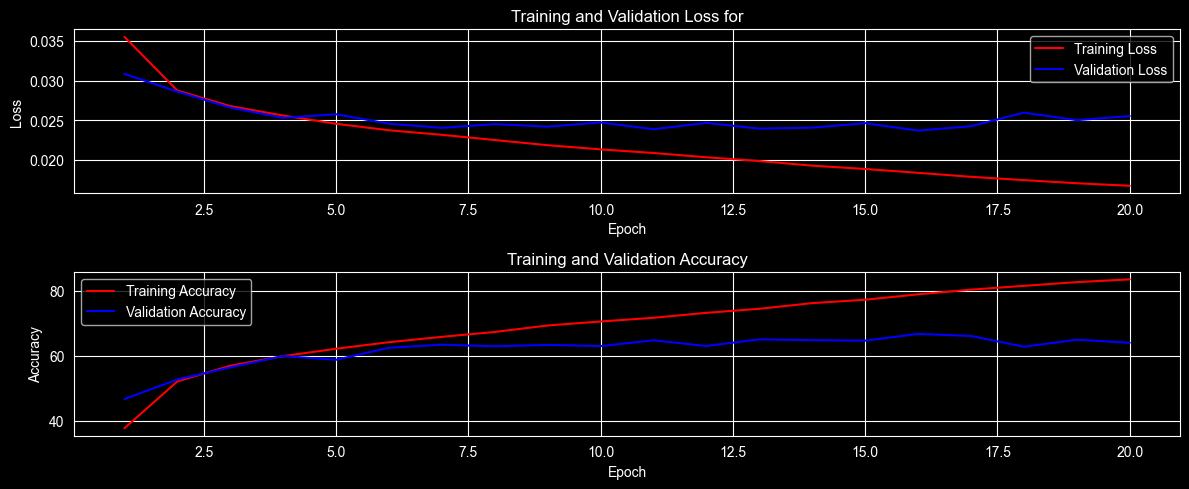

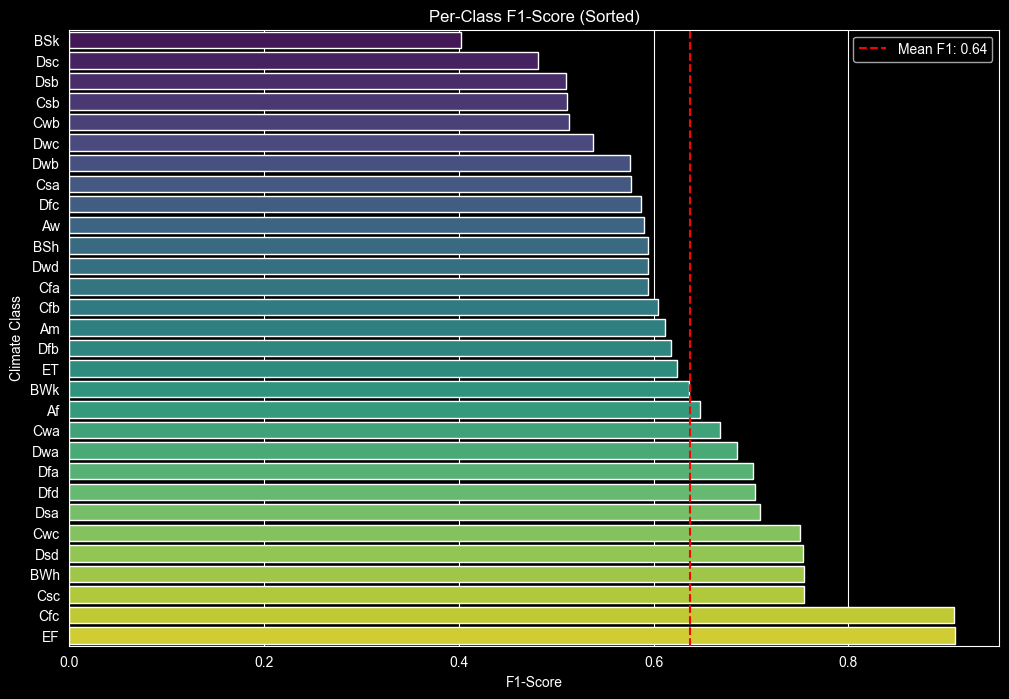

In [16]:
plt.figure(figsize=(12, 5))

# Plot the losses
plt.subplot(2, 1, 1)
plt.plot(np.arange(1, epochs + 1), train_loss, 'r-', label='Training Loss')
plt.plot(np.arange(1, epochs + 1), val_loss, 'b-', label='Validation Loss')
plt.title('Training and Validation Loss for')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot the accuracies
plt.subplot(2, 1, 2)
plt.plot(np.arange(1, epochs + 1), train_acc, 'r-', label='Training Accuracy')
plt.plot(np.arange(1, epochs + 1), val_acc, 'b-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plot_per_class_f1()